In [4]:
# !pip install pandas_datareader
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr
import warnings
warnings.filterwarnings('ignore')

# Define time horizon
start = "2010-01-01"
end = "2024-01-01"

# Fetch a focused set of macro indicators
series = {
    "CPIAUCSL": "cpi",      # Consumer Price Index
    "UNRATE": "unrate",     # Unemployment Rate
    "FEDFUNDS": "fedfunds", # Fed Funds Rate
    "INDPRO": "indpro",     # Industrial Production
    "M2SL": "m2"            # M2 Money Supply
}

# Pull data, normalize to monthly start, and drop NAs
df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1).resample("MS").mean().dropna()
display(df.head())

,cpi,unrate,fedfunds,indpro,m2
DATE,,,,,
2010-01-01,217.488,9.8,0.11,89.3426,8477.7
2010-02-01,217.281,9.8,0.13,89.6779,8527.3
2010-03-01,217.353,9.9,0.16,90.2928,8523.5
2010-04-01,217.403,9.9,0.20,90.5991,8554.8
2010-05-01,217.290,9.6,0.20,91.8230,8609.0


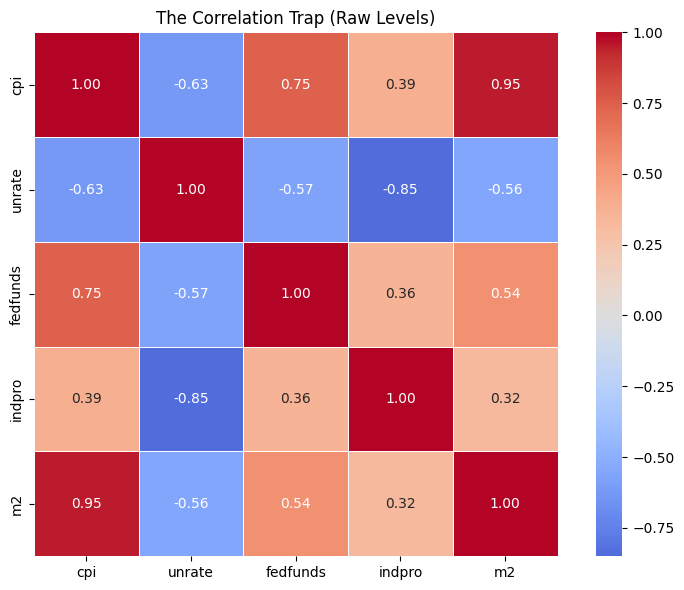

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("The Correlation Trap (Raw Levels)")
plt.tight_layout()
plt.show()

In [6]:
# Define predictors (X). We leave out CPI as it is our theoretical target.
X = df[['unrate', 'fedfunds', 'indpro', 'm2']]
X = sm.add_constant(X)  # Statsmodels requires a constant for VIF

# Calculate VIF iteratively
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i) for i in range(X.shape[1])
]

display(vif_data)

,Feature,VIF
0,const,4252.825829
1,unrate,6.206882
2,fedfunds,1.727582
3,indpro,4.290455
4,m2,1.780273


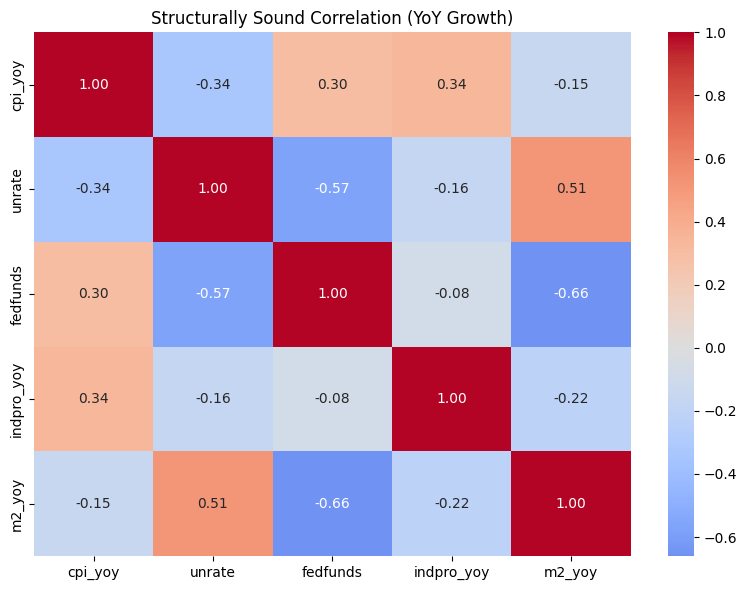

In [7]:
df_t = df.copy()

# Transform trending variables to YoY growth (%)
# pct_change(12) is equivalent but this form makes the math explicit:
# YoY % = 100 * (current_value / value_12_months_ago - 1)
for col in ["cpi", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = 100 * (df_t[col] / df_t[col].shift(12) - 1)

# Drop missing values created by the 12-month shift
# The first 12 rows will be NaN since there's no prior-year value to compare
df_t = df_t.dropna()

# Visualize the corrected correlations
cols_to_keep = ['cpi_yoy', 'unrate', 'fedfunds', 'indpro_yoy', 'm2_yoy']
plt.figure(figsize=(8, 6))
sns.heatmap(df_t[cols_to_keep].corr(), annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Structurally Sound Correlation (YoY Growth)")
plt.tight_layout()
plt.show()

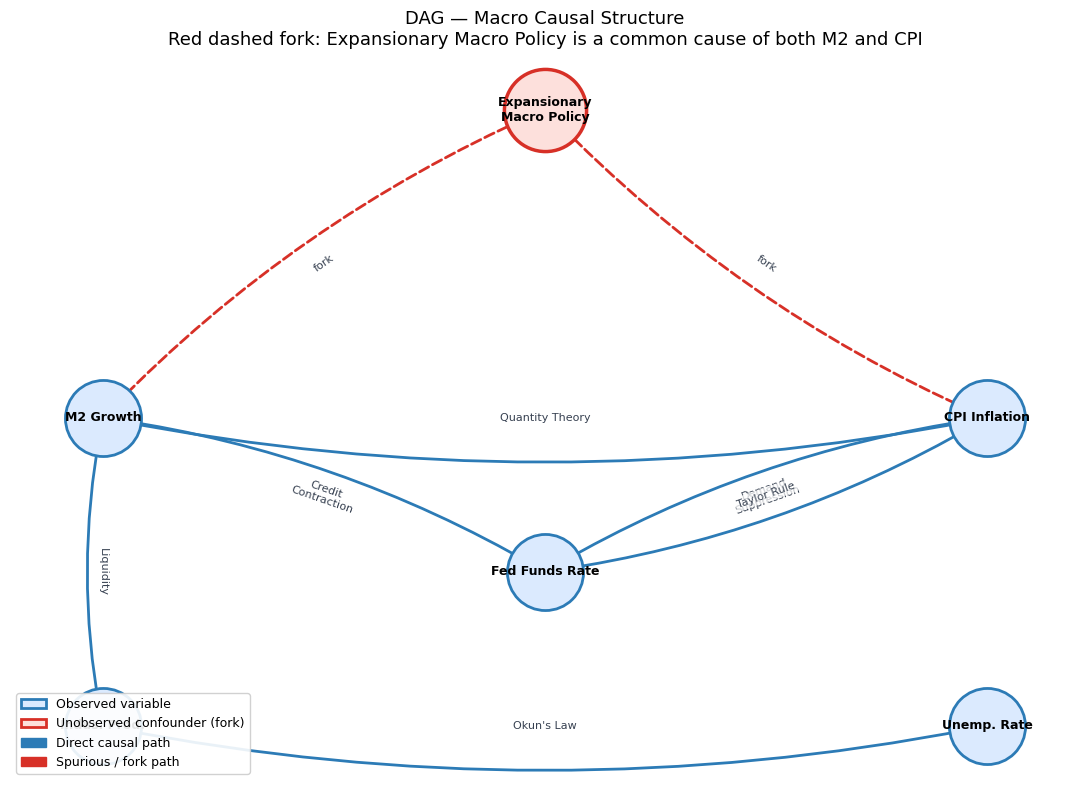

In [8]:
import networkx as nx

# ── Build the DAG ──────────────────────────────────────────────────────────
G = nx.DiGraph()

# Define edges (src, dst) encoding your causal assumptions
edges = [
    # Expansionary Macro Policy is the unobserved fork / common cause
    ("Expansionary\nMacro Policy", "M2 Growth"),
    ("Expansionary\nMacro Policy", "CPI Inflation"),

    # Direct structural paths
    ("M2 Growth",       "CPI Inflation"),    # Quantity Theory of Money
    ("Fed Funds Rate",  "CPI Inflation"),    # Demand suppression via rate hikes
    ("Fed Funds Rate",  "M2 Growth"),        # Tighter policy contracts money supply
    ("CPI Inflation",   "Fed Funds Rate"),   # Taylor Rule feedback loop
    ("Indus. Prod.",    "Unemp. Rate"),      # Okun's Law
    ("M2 Growth",       "Indus. Prod."),     # Liquidity fuels real activity
]

G.add_edges_from(edges)

# ── Layout & visual grouping ───────────────────────────────────────────────
pos = {
    "Expansionary\nMacro Policy": (0,  2),
    "M2 Growth":                  (-2, 0),
    "CPI Inflation":              (2,  0),
    "Fed Funds Rate":             (0, -1),
    "Indus. Prod.":               (-2, -2),
    "Unemp. Rate":                (2, -2),
}

# Separate confounder from structural nodes for distinct styling
confounder   = ["Expansionary\nMacro Policy"]
struct_nodes = [n for n in G.nodes if n not in confounder]

# ── Draw ───────────────────────────────────────────────────────────────────
plt.figure(figsize=(11, 8))

# Structural nodes (blue)
nx.draw_networkx_nodes(G, pos, nodelist=struct_nodes,
                       node_color="#dbeafe", node_size=3000,
                       edgecolors="#2c7bb6", linewidths=2)

# Confounder node (red, dashed border)
nx.draw_networkx_nodes(G, pos, nodelist=confounder,
                       node_color="#fde0dc", node_size=3500,
                       edgecolors="#d73027", linewidths=2.5)

nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

# Fork edges from confounder (red dashed)
fork_edges   = [(u, v) for u, v in G.edges if u in confounder]
struct_edges = [(u, v) for u, v in G.edges if u not in confounder]

nx.draw_networkx_edges(G, pos, edgelist=struct_edges,
                       arrows=True, arrowsize=25,
                       edge_color="#2c7bb6", width=2,
                       connectionstyle="arc3,rad=0.1")

nx.draw_networkx_edges(G, pos, edgelist=fork_edges,
                       arrows=True, arrowsize=25,
                       edge_color="#d73027", width=2, style="dashed",
                       connectionstyle="arc3,rad=0.1")

# Edge labels
edge_labels = {
    ("Expansionary\nMacro Policy", "M2 Growth"):      "fork",
    ("Expansionary\nMacro Policy", "CPI Inflation"):  "fork",
    ("M2 Growth",      "CPI Inflation"):   "Quantity Theory",
    ("Fed Funds Rate", "CPI Inflation"):   "Demand\nSuppression",
    ("Fed Funds Rate", "M2 Growth"):       "Credit\nContraction",
    ("CPI Inflation",  "Fed Funds Rate"):  "Taylor Rule",
    ("M2 Growth",      "Indus. Prod."):    "Liquidity",
    ("Indus. Prod.",   "Unemp. Rate"):     "Okun's Law",
}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                             font_size=8, font_color="#374151",
                             bbox=dict(boxstyle="round,pad=0.2",
                                       facecolor="white", alpha=0.75, lw=0))

# Legend
from matplotlib.patches import Patch, FancyArrow
legend_elements = [
    Patch(facecolor="#dbeafe", edgecolor="#2c7bb6", lw=2,  label="Observed variable"),
    Patch(facecolor="#fde0dc", edgecolor="#d73027", lw=2,  label="Unobserved confounder (fork)"),
    FancyArrow(0, 0, 1, 0, color="#2c7bb6", width=0.3,     label="Direct causal path"),
    FancyArrow(0, 0, 1, 0, color="#d73027", width=0.3,     label="Spurious / fork path"),
]
plt.legend(handles=legend_elements, loc="lower left", fontsize=9, framealpha=0.9)

plt.title("DAG — Macro Causal Structure\n"
          "Red dashed fork: Expansionary Macro Policy is a common cause of both M2 and CPI",
          fontsize=13, pad=12)
plt.axis("off")
plt.tight_layout()
plt.show()

The Fork — "Expansionary Macro Policy" simultaneously causes both M2 Growth and CPI Inflation. This means the raw M2/CPI correlation is partly spurious: it blends the direct M2→CPI path (Quantity Theory) with the shared upstream cause. Naively regressing CPI on M2 without accounting for the fork overstates M2's direct effect.
The Feedback Loop — CPI↑ triggers Fed Funds↑ (Taylor Rule), which in turn suppresses M2 and CPI. This cycle means fedfunds is both a cause and a collider in certain paths — conditioning on it carelessly can open backdoor paths and introduce bias rather than remove it.
Okun's Law chain — M2→IndPro→Unemployment is a mediated path: money supply expansion fuels real activity, which absorbs labor. Controlling for IndPro when predicting unemployment would block this mediation and understate M2's total effect.

In [10]:
import plotly.graph_objects as go
import numpy as np

# ── 1. BUILD BOTH CORRELATION MATRICES ────────────────────────────────────

# Raw levels: all 5 original columns
cols_raw = ['cpi', 'unrate', 'fedfunds', 'indpro', 'm2']
corr_raw = df[cols_raw].corr()

# YoY transformed: trending variables replaced with growth rates
cols_yoy = ['cpi_yoy', 'unrate', 'fedfunds', 'indpro_yoy', 'm2_yoy']
corr_yoy = df_t[cols_yoy].corr()

# Readable axis labels (shared across both views)
labels = ['CPI', 'Unemp.', 'Fed Funds', 'Ind. Prod.', 'M2']

# ── 2. PRE-COMPUTE ANNOTATION TEXT FOR EACH MATRIX ────────────────────────
# Plotly heatmaps don't auto-annotate; we build a text matrix manually.

def make_annotations(corr_matrix):
    """Return a 2D list of strings like '0.97' for each cell."""
    return [[f"{corr_matrix.iloc[i, j]:.2f}"
             for j in range(corr_matrix.shape[1])]
            for i in range(corr_matrix.shape[0])]

text_raw = make_annotations(corr_raw)
text_yoy = make_annotations(corr_yoy)

# ── 3. CREATE THE BASE FIGURE WITH TWO TRACES ──────────────────────────────
# Both traces are added upfront; the dropdown toggles visibility between them.
# This is the core architecture: data lives in traces, dropdown controls
# which trace is visible via the `visible` property in `updatemenus`.

fig = go.Figure()

# Trace 0 — Raw Levels (visible by default)
fig.add_trace(go.Heatmap(
    z=corr_raw.values,
    x=labels,
    y=labels,
    text=text_raw,
    texttemplate="%{text}",
    colorscale="RdBu",
    zmin=-1, zmax=1,
    reversescale=True,
    colorbar=dict(title="r"),
    visible=True
))

# Trace 1 — YoY Growth (hidden on load)
fig.add_trace(go.Heatmap(
    z=corr_yoy.values,
    x=labels,
    y=labels,
    text=text_yoy,
    texttemplate="%{text}",
    colorscale="RdBu",
    zmin=-1, zmax=1,
    reversescale=True,
    colorbar=dict(title="r"),
    visible=False
))

# ── 4. DEFINE THE DROPDOWN (updatemenus) ──────────────────────────────────

fig.update_layout(
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        x=0.01, xanchor="left",
        y=1.18, yanchor="top",
        showactive=True,
        bgcolor="#f0f4f8",
        bordercolor="#94a3b8",
        font=dict(size=13),
        buttons=[
            dict(
                label="Raw Levels",
                method="update",
                args=[
                    {"visible": [True, False]},
                    {"title.text": "Correlation Matrix — Raw Levels<br><sup>Spurious trend-driven correlations</sup>"}
                ]
            ),
            dict(
                label="YoY Growth Rates",
                method="update",
                args=[
                    {"visible": [False, True]},
                    {"title.text": "Correlation Matrix — YoY Growth Rates<br><sup>Structurally sound correlations</sup>"}
                ]
            ),
        ]
    )],

    title=dict(
        text="Correlation Matrix — Raw Levels<br><sup>Spurious trend-driven correlations</sup>",
        x=0.5, xanchor="center", font=dict(size=16)
    ),
    width=620, height=580,
    margin=dict(t=120, l=80, r=40, b=80),
    font=dict(family="monospace", size=12),
    paper_bgcolor="#f8fafc",
    plot_bgcolor="#f8fafc",
)

# ── 5. AXIS STYLING ────────────────────────────────────────────────────────

fig.update_xaxes(tickangle=-30, tickfont=dict(size=11))
fig.update_yaxes(autorange="reversed", tickfont=dict(size=11))

fig.show()